In [1]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote
from matplotlib import pyplot as plt
import seaborn as sns

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
# параметры подключения
username = "student"
password = "123456sql@"
host = "rc1b-cpsjckr2wfkuk61s.mdb.yandexcloud.net"
port = "6432"
database = "Northwind"

# Кодируем пароль
encoded_password = quote(password)
print(encoded_password)

# Формируем строку подключения
connection_string = f'postgresql+psycopg2://{username}:{encoded_password}@{host}:{port}/{database}'
engine = create_engine(connection_string)

123456sql%40


In [3]:
#sql запрос
query = """
    select category_name, 
          date(date_created) as date_created,
    sum(quantity * price) as gmv_created
    from sandbox.orders o join  sandbox.order_details od on o.order_id = od.order_id 
    group by category_name, date(date_created)
    order by category_name, date(date_created)
    """
df = pd.read_sql_query(query, engine)
df.head()

,category_name,date_created,gmv_created
0,Automotive & Industrial,2017-01-05,21.80
1,Automotive & Industrial,2017-01-16,970.39
2,Automotive & Industrial,2017-01-17,109.20
3,Automotive & Industrial,2017-01-18,117.30
4,Automotive & Industrial,2017-01-19,152.30


In [4]:
df['date_created'] = df.date_created.astype('datetime64[ns]')
df['month_created'] = df.date_created.astype('datetime64[ns]').dt.to_period('M').dt.to_timestamp()
df['week_created'] = df.date_created.astype('datetime64[ns]').dt.to_period('W').dt.to_timestamp()

In [5]:
df_monthly = df.groupby(['category_name', 'month_created'], as_index = False).gmv_created.sum()
df_monthly.head()

,category_name,month_created,gmv_created
0,Automotive & Industrial,2017-01-01,5732.99
1,Automotive & Industrial,2017-02-01,16513.71
2,Automotive & Industrial,2017-03-01,18085.63
3,Automotive & Industrial,2017-04-01,18708.51
4,Automotive & Industrial,2017-05-01,22163.20


#### Анализируем категории в динамике

Фильтруем по категории смотрим динамику в табличном виде

In [6]:
df_monthly[df_monthly['category_name'] == 'Pet Supplies']

,category_name,month_created,gmv_created
133,Pet Supplies,2017-01-01,967.12
134,Pet Supplies,2017-02-01,3584.87
135,Pet Supplies,2017-03-01,8369.96
136,Pet Supplies,2017-04-01,6182.89
137,Pet Supplies,2017-05-01,8151.02
138,Pet Supplies,2017-06-01,5243.57
139,Pet Supplies,2017-07-01,6605.87
140,Pet Supplies,2017-08-01,10425.79
141,Pet Supplies,2017-09-01,8534.92
142,Pet Supplies,2017-10-01,8243.58


Делаем сводую, смотрим динамику по всем категориям

In [7]:
df_pivot = df_monthly.pivot(index = 'category_name', columns = 'month_created', values = 'gmv_created')

In [8]:
df_pivot

month_created,2017-01-01,2017-02-01,2017-03-01,2017-04-01,2017-05-01,2017-06-01,2017-07-01,2017-08-01,2017-09-01,2017-10-01,2017-11-01,2017-12-01,2018-01-01,2018-02-01,2018-03-01,2018-04-01,2018-05-01,2018-06-01,2018-07-01
category_name,,,,,,,,,,,,,,,,,,,
Automotive & Industrial,5732.99,16513.71,18085.63,18708.51,22163.20,33632.52,17993.44,26205.84,22207.92,35656.31,66059.91,55380.32,63659.36,73445.48,73260.03,82041.37,77817.29,86972.56,29726.53
Baby Products,6217.88,2872.58,3604.18,3980.45,9283.62,7864.74,15461.41,19762.33,23412.44,16497.50,21178.18,19943.18,30156.67,26046.24,41381.04,49801.91,33420.65,31076.12,8271.07
Electronics & Computers,12706.58,28903.85,52870.05,36855.17,67417.32,53657.05,61896.39,94490.26,125536.22,123891.86,133504.09,89287.60,134594.74,149754.54,148680.06,115311.19,108508.94,98825.51,40345.59
Fashion & Accessories,10627.34,16420.66,38305.29,35873.85,60670.25,45344.94,50937.89,53474.08,66957.86,82037.54,121620.07,89631.98,103245.57,81450.26,115354.70,111737.25,141906.48,101724.06,47375.20
Food & Beverages,42.82,676.73,3112.23,763.13,1016.39,257.29,1496.32,1292.21,1548.76,3837.27,3888.13,4170.86,3590.34,4959.96,5262.37,7566.94,5288.36,3232.10,1461.28
Health & Beauty,17533.94,30249.42,45735.48,42083.36,66680.07,56163.90,47410.65,62449.22,65759.92,58609.77,110428.96,87861.40,92252.58,107585.86,106602.61,109469.35,119854.67,135131.85,49448.46
Home & Garden,32478.94,77146.73,103463.41,95595.06,128221.51,110160.98,162303.10,165632.64,147334.26,156108.90,284710.51,162602.86,251448.24,217714.34,253893.00,292953.03,293541.65,240429.74,91930.22
Pet Supplies,967.12,3584.87,8369.96,6182.89,8151.02,5243.57,6605.87,10425.79,8534.92,8243.58,11267.69,7159.73,10885.96,9575.04,13643.69,18556.50,11708.46,19491.78,6217.98
Small Appliances,1660.79,7251.58,11171.06,23253.98,5241.44,9770.71,3587.23,4318.91,10671.73,6464.85,6782.92,7539.77,15390.85,8270.06,21912.08,26052.74,20782.59,19521.70,7378.43


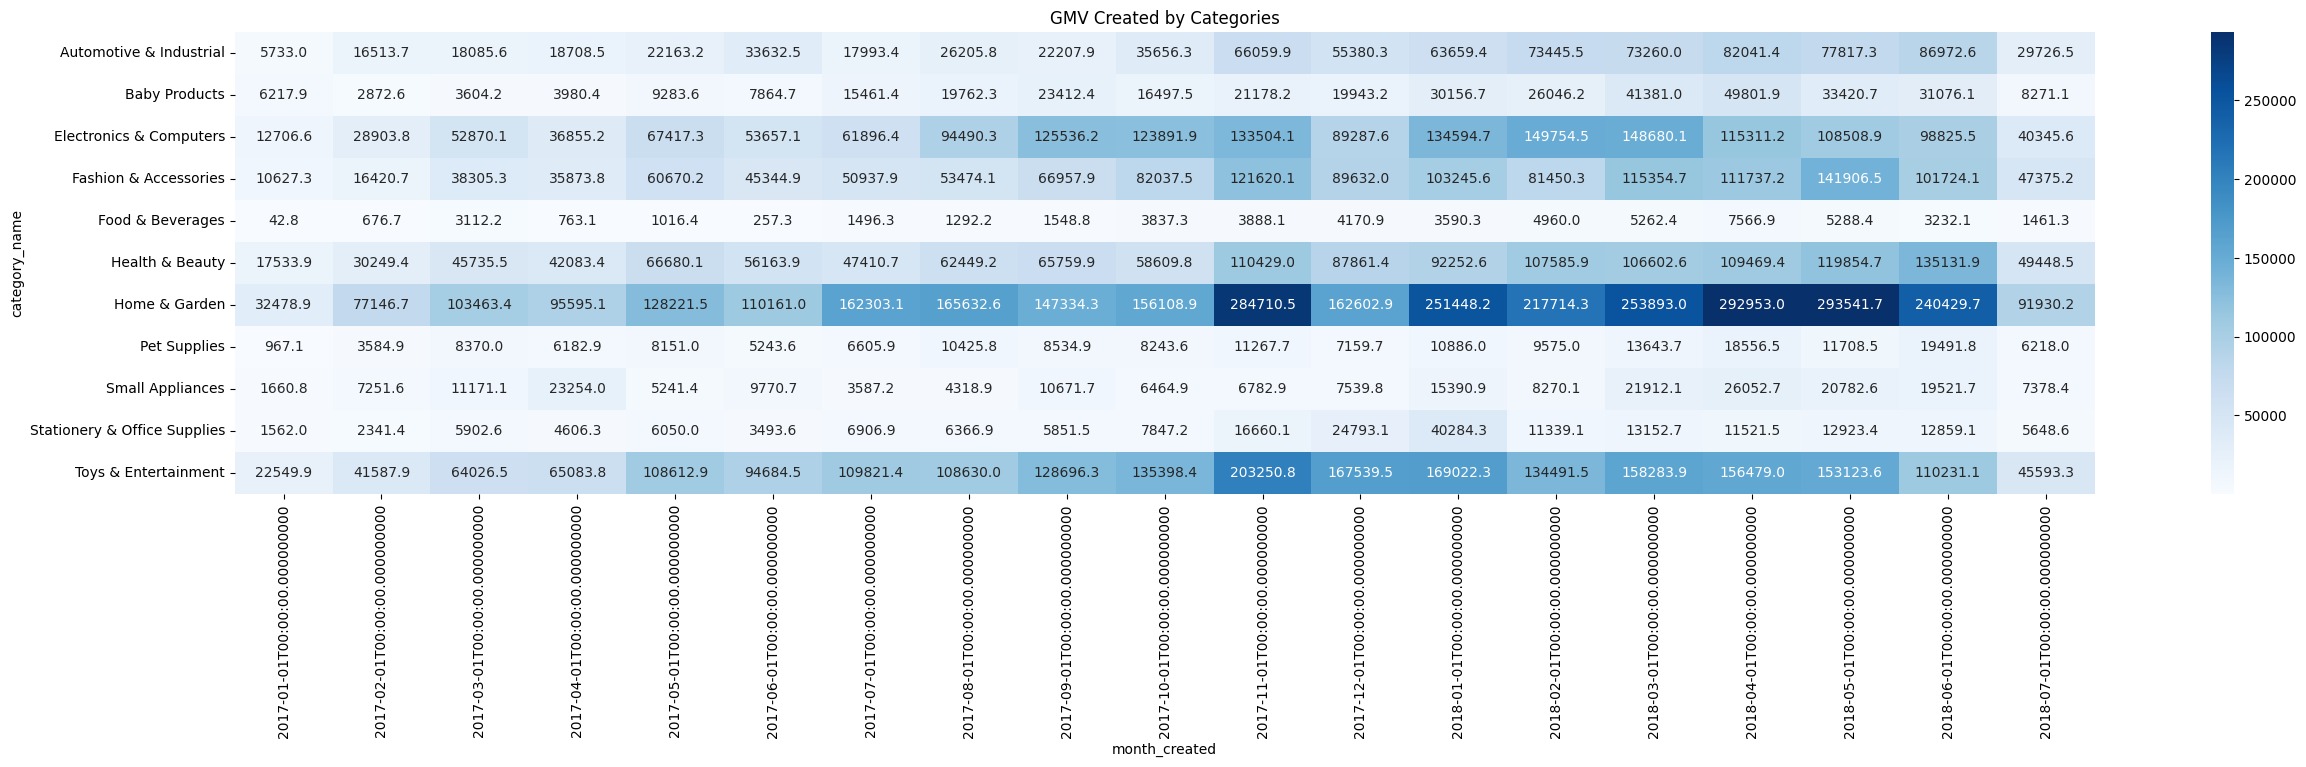

In [9]:
# Построение графика
plt.figure(figsize=(30, 6))
sns.heatmap(df_pivot, annot=True, fmt=".1f", cmap='Blues')
plt.title('GMV Created by Categories')
#plt.ylabel('GMV Creared')
#plt.xlabel('Month')
plt.show()

Можем построить линейную динамику по всем категориям

/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


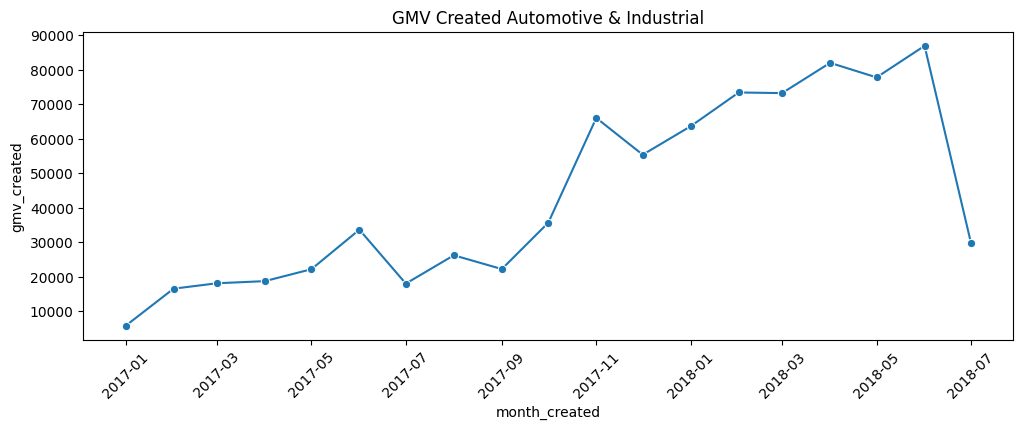

/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


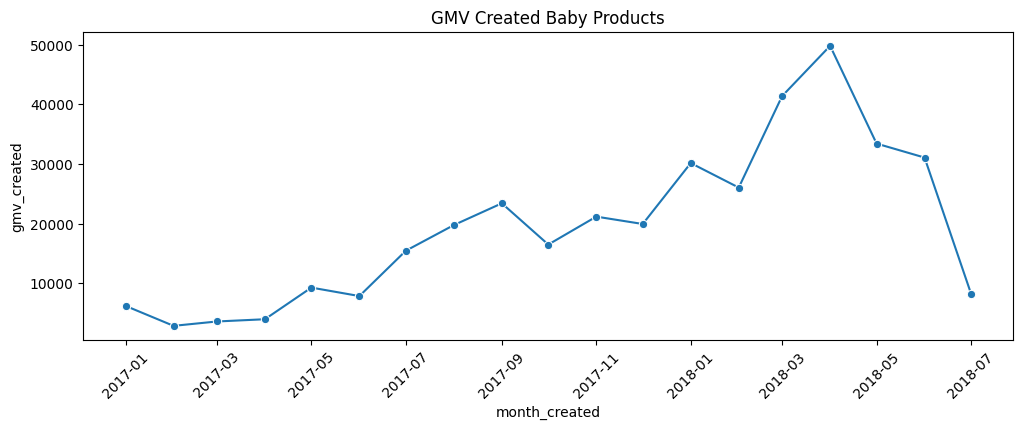

/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


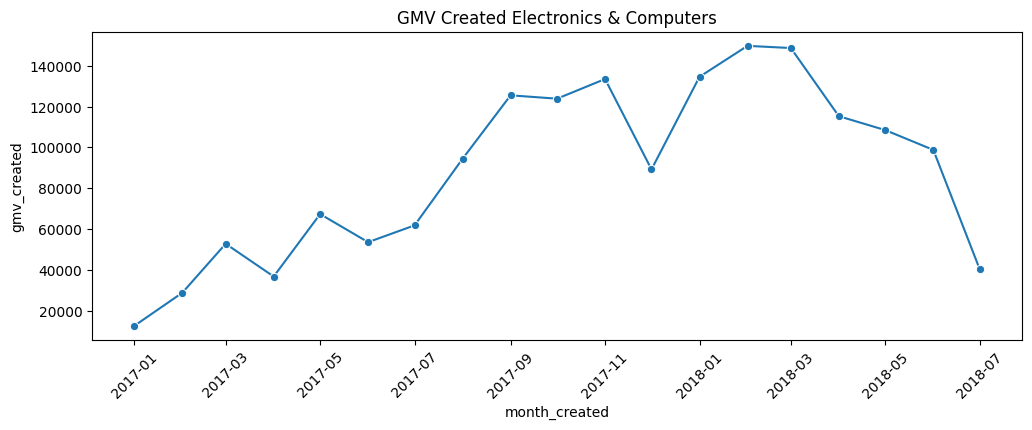

/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


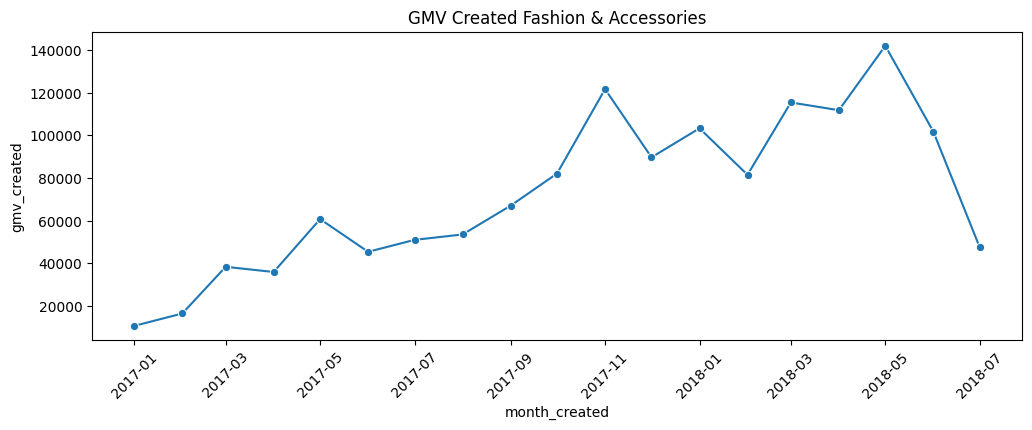

/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


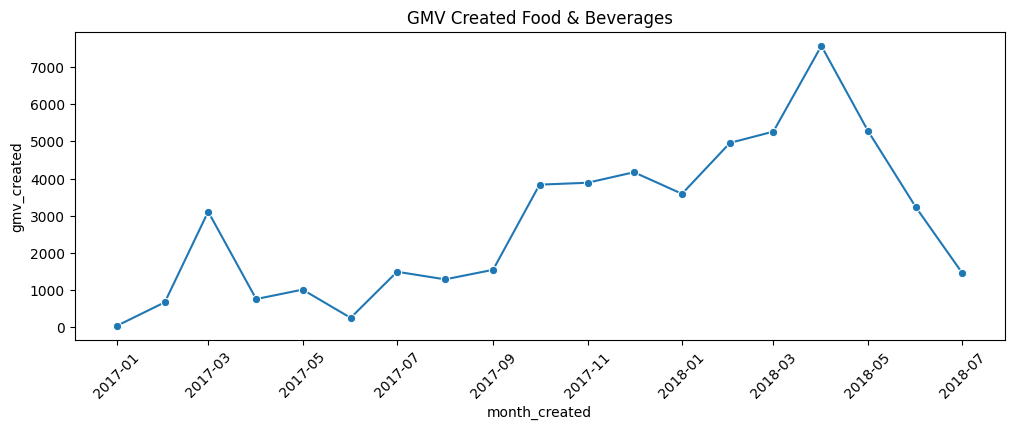

/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


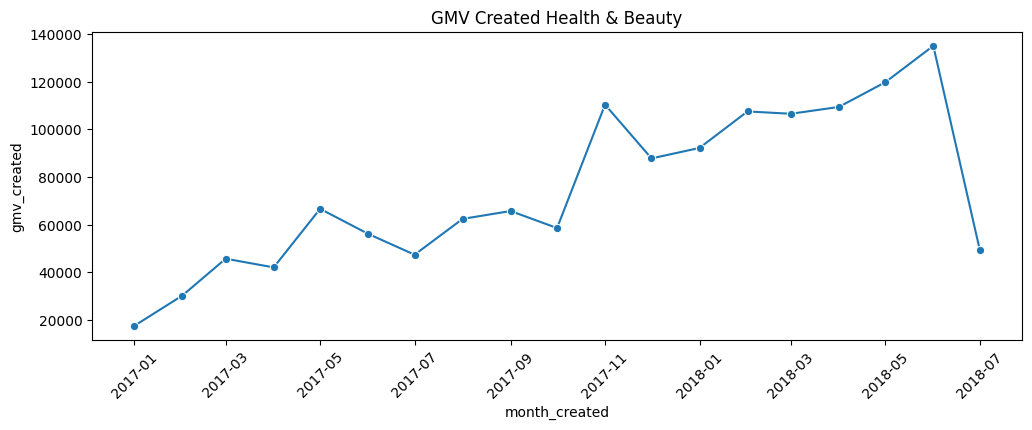

/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


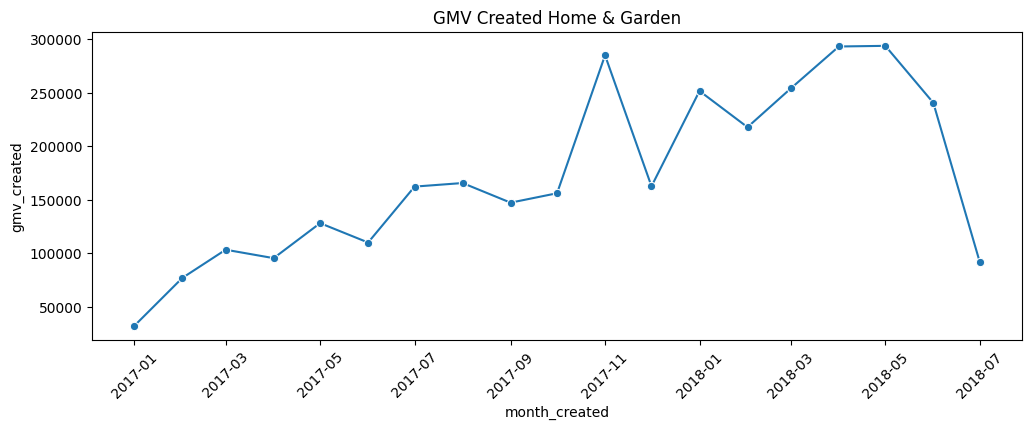

/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


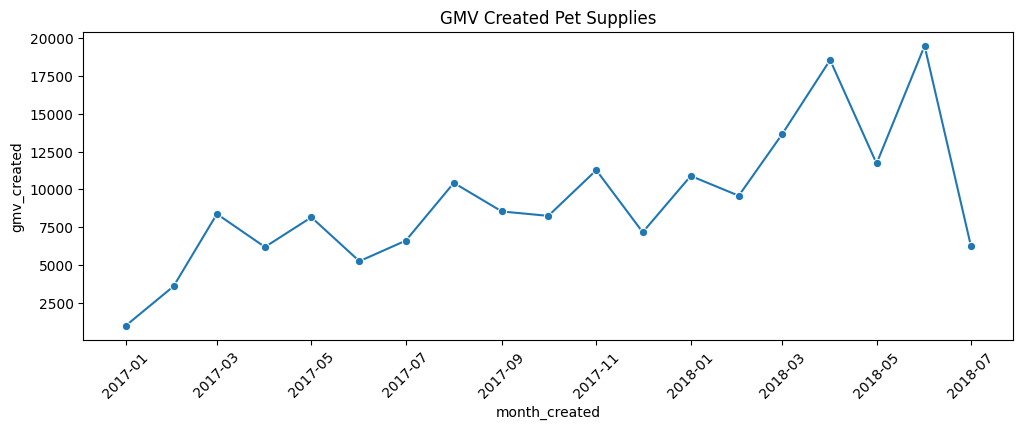

/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


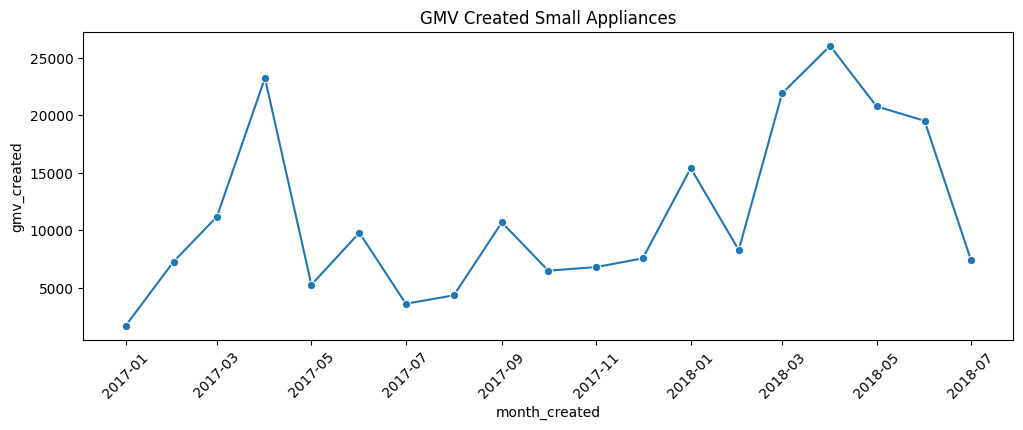

/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


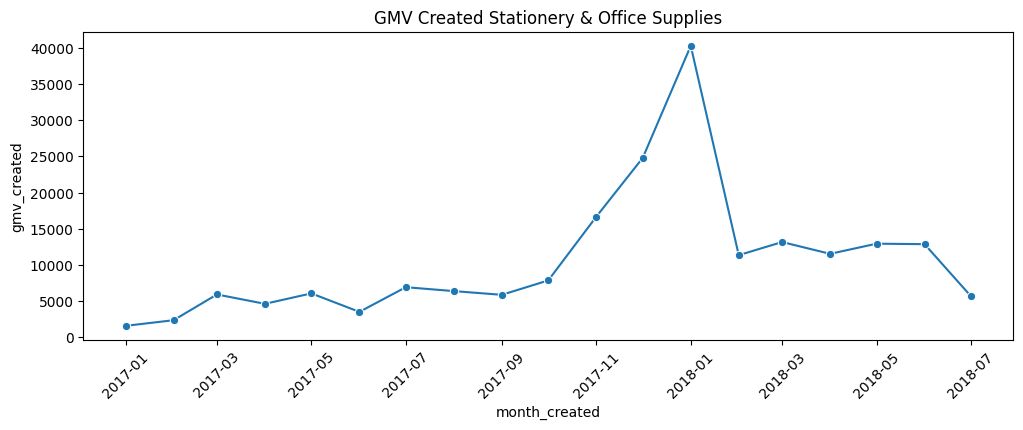

/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


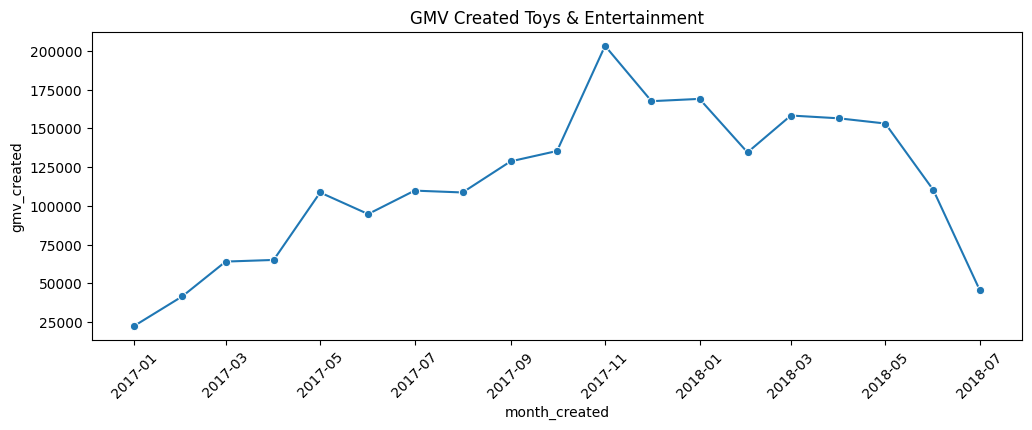

In [11]:
for i in df_monthly.category_name.unique():
    # Построение графика
    plt.figure(figsize=(12, 4))
    sns.lineplot(data=df_monthly[df_monthly['category_name'] == i], x='month_created', y='gmv_created', marker='o')# Установка меток для оси X
    plt.xticks(rotation=45)  # Поворот меток для лучшей читаемости
    plt.title(f'GMV Created {i}')
    
    plt.show()

Можем построить линеюную динамику по всем категориям на одном чарте

/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


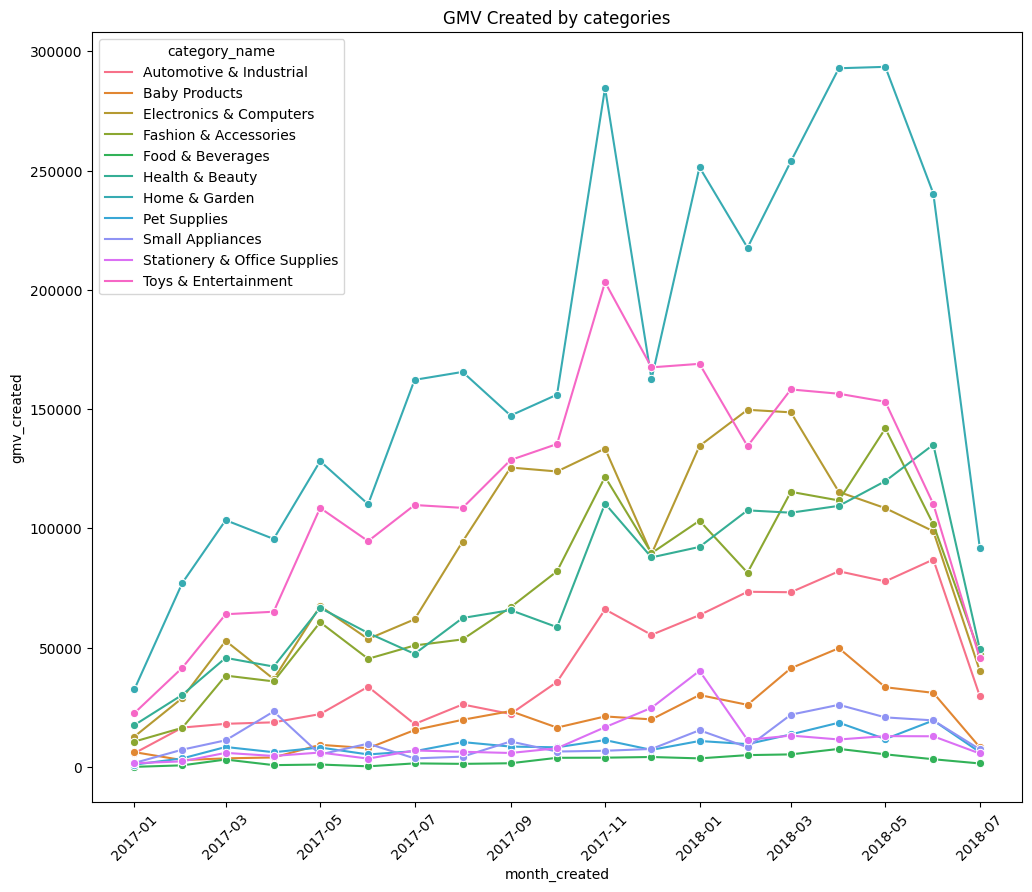

In [12]:
# Построение графика
plt.figure(figsize=(12, 10))
sns.lineplot(data = df_monthly, x = 'month_created', y='gmv_created', marker='o',  hue= 'category_name')# Установка меток для оси X
plt.xticks(rotation=45)  # Поворот меток для лучшей читаемости
plt.title(f'GMV Created by categories')
plt.show()

In [13]:
df_pivot

month_created,2017-01-01,2017-02-01,2017-03-01,2017-04-01,2017-05-01,2017-06-01,2017-07-01,2017-08-01,2017-09-01,2017-10-01,2017-11-01,2017-12-01,2018-01-01,2018-02-01,2018-03-01,2018-04-01,2018-05-01,2018-06-01,2018-07-01
category_name,,,,,,,,,,,,,,,,,,,
Automotive & Industrial,5732.99,16513.71,18085.63,18708.51,22163.20,33632.52,17993.44,26205.84,22207.92,35656.31,66059.91,55380.32,63659.36,73445.48,73260.03,82041.37,77817.29,86972.56,29726.53
Baby Products,6217.88,2872.58,3604.18,3980.45,9283.62,7864.74,15461.41,19762.33,23412.44,16497.50,21178.18,19943.18,30156.67,26046.24,41381.04,49801.91,33420.65,31076.12,8271.07
Electronics & Computers,12706.58,28903.85,52870.05,36855.17,67417.32,53657.05,61896.39,94490.26,125536.22,123891.86,133504.09,89287.60,134594.74,149754.54,148680.06,115311.19,108508.94,98825.51,40345.59
Fashion & Accessories,10627.34,16420.66,38305.29,35873.85,60670.25,45344.94,50937.89,53474.08,66957.86,82037.54,121620.07,89631.98,103245.57,81450.26,115354.70,111737.25,141906.48,101724.06,47375.20
Food & Beverages,42.82,676.73,3112.23,763.13,1016.39,257.29,1496.32,1292.21,1548.76,3837.27,3888.13,4170.86,3590.34,4959.96,5262.37,7566.94,5288.36,3232.10,1461.28
Health & Beauty,17533.94,30249.42,45735.48,42083.36,66680.07,56163.90,47410.65,62449.22,65759.92,58609.77,110428.96,87861.40,92252.58,107585.86,106602.61,109469.35,119854.67,135131.85,49448.46
Home & Garden,32478.94,77146.73,103463.41,95595.06,128221.51,110160.98,162303.10,165632.64,147334.26,156108.90,284710.51,162602.86,251448.24,217714.34,253893.00,292953.03,293541.65,240429.74,91930.22
Pet Supplies,967.12,3584.87,8369.96,6182.89,8151.02,5243.57,6605.87,10425.79,8534.92,8243.58,11267.69,7159.73,10885.96,9575.04,13643.69,18556.50,11708.46,19491.78,6217.98
Small Appliances,1660.79,7251.58,11171.06,23253.98,5241.44,9770.71,3587.23,4318.91,10671.73,6464.85,6782.92,7539.77,15390.85,8270.06,21912.08,26052.74,20782.59,19521.70,7378.43


Считаем прирост GMV Created в категориях

In [14]:
df_delta = round((df_pivot['2018-06-01']/df_pivot['2018-05-01']-1) * 100 ,1).reset_index().rename(columns = {0:'delta'})
df_delta

,category_name,delta
0,Automotive & Industrial,11.8
1,Baby Products,-7.0
2,Electronics & Computers,-8.9
3,Fashion & Accessories,-28.3
4,Food & Beverages,-38.9
5,Health & Beauty,12.7
6,Home & Garden,-18.1
7,Pet Supplies,66.5
8,Small Appliances,-6.1
9,Stationery & Office Supplies,-0.5


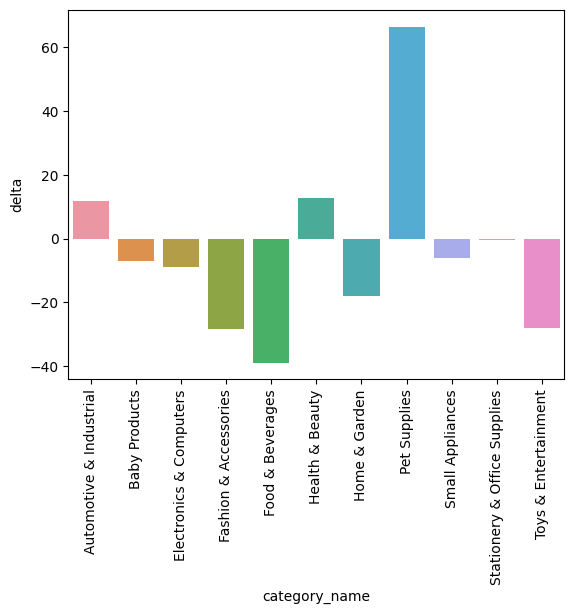

In [15]:
#визуализация приростов
sns.barplot(data = df_delta, x = df_delta.category_name, y = df_delta.delta)
plt.xticks(rotation = 90)
plt.show()

In [16]:
df_pivot

month_created,2017-01-01,2017-02-01,2017-03-01,2017-04-01,2017-05-01,2017-06-01,2017-07-01,2017-08-01,2017-09-01,2017-10-01,2017-11-01,2017-12-01,2018-01-01,2018-02-01,2018-03-01,2018-04-01,2018-05-01,2018-06-01,2018-07-01
category_name,,,,,,,,,,,,,,,,,,,
Automotive & Industrial,5732.99,16513.71,18085.63,18708.51,22163.20,33632.52,17993.44,26205.84,22207.92,35656.31,66059.91,55380.32,63659.36,73445.48,73260.03,82041.37,77817.29,86972.56,29726.53
Baby Products,6217.88,2872.58,3604.18,3980.45,9283.62,7864.74,15461.41,19762.33,23412.44,16497.50,21178.18,19943.18,30156.67,26046.24,41381.04,49801.91,33420.65,31076.12,8271.07
Electronics & Computers,12706.58,28903.85,52870.05,36855.17,67417.32,53657.05,61896.39,94490.26,125536.22,123891.86,133504.09,89287.60,134594.74,149754.54,148680.06,115311.19,108508.94,98825.51,40345.59
Fashion & Accessories,10627.34,16420.66,38305.29,35873.85,60670.25,45344.94,50937.89,53474.08,66957.86,82037.54,121620.07,89631.98,103245.57,81450.26,115354.70,111737.25,141906.48,101724.06,47375.20
Food & Beverages,42.82,676.73,3112.23,763.13,1016.39,257.29,1496.32,1292.21,1548.76,3837.27,3888.13,4170.86,3590.34,4959.96,5262.37,7566.94,5288.36,3232.10,1461.28
Health & Beauty,17533.94,30249.42,45735.48,42083.36,66680.07,56163.90,47410.65,62449.22,65759.92,58609.77,110428.96,87861.40,92252.58,107585.86,106602.61,109469.35,119854.67,135131.85,49448.46
Home & Garden,32478.94,77146.73,103463.41,95595.06,128221.51,110160.98,162303.10,165632.64,147334.26,156108.90,284710.51,162602.86,251448.24,217714.34,253893.00,292953.03,293541.65,240429.74,91930.22
Pet Supplies,967.12,3584.87,8369.96,6182.89,8151.02,5243.57,6605.87,10425.79,8534.92,8243.58,11267.69,7159.73,10885.96,9575.04,13643.69,18556.50,11708.46,19491.78,6217.98
Small Appliances,1660.79,7251.58,11171.06,23253.98,5241.44,9770.71,3587.23,4318.91,10671.73,6464.85,6782.92,7539.77,15390.85,8270.06,21912.08,26052.74,20782.59,19521.70,7378.43


считаем долю по столбцу

In [17]:
round((df_pivot['2017-01-01'] / df_pivot['2017-01-01'].sum()) * 100,1)

category_name
Automotive & Industrial          5.1
Baby Products                    5.5
Electronics & Computers         11.3
Fashion & Accessories            9.5
Food & Beverages                 0.0
Health & Beauty                 15.6
Home & Garden                   29.0
Pet Supplies                     0.9
Small Appliances                 1.5
Stationery & Office Supplies     1.4
Toys & Entertainment            20.1
Name: 2017-01-01 00:00:00, dtype: float64

In [20]:
for i in df_pivot.columns:
    df_pivot[str(i) +'_' + 'shares'] = round(df_pivot[i] / df_pivot[i].sum() * 100,1)

In [21]:
df_pivot

month_created,2017-01-01 00:00:00,2017-02-01 00:00:00,2017-03-01 00:00:00,2017-04-01 00:00:00,2017-05-01 00:00:00,2017-06-01 00:00:00,2017-07-01 00:00:00,2017-08-01 00:00:00,2017-09-01 00:00:00,2017-10-01 00:00:00,2017-11-01 00:00:00,2017-12-01 00:00:00,2018-01-01 00:00:00,2018-02-01 00:00:00,2018-03-01 00:00:00,2018-04-01 00:00:00,2018-05-01 00:00:00,2018-06-01 00:00:00,2018-07-01 00:00:00,2017-01-01 00:00:00_shares,2017-02-01 00:00:00_shares,2017-03-01 00:00:00_shares,2017-04-01 00:00:00_shares,2017-05-01 00:00:00_shares,2017-06-01 00:00:00_shares,2017-07-01 00:00:00_shares,2017-08-01 00:00:00_shares,2017-09-01 00:00:00_shares,2017-10-01 00:00:00_shares,2017-11-01 00:00:00_shares,2017-12-01 00:00:00_shares,2018-01-01 00:00:00_shares,2018-02-01 00:00:00_shares,2018-03-01 00:00:00_shares,2018-04-01 00:00:00_shares,2018-05-01 00:00:00_shares,2018-06-01 00:00:00_shares,2018-07-01 00:00:00_shares,2017-01-01 00:00:00_shares_shares,2017-02-01 00:00:00_shares_shares,2017-03-01 00:00:00_shares_shares,2017-04-01 00:00:00_shares_shares,2017-05-01 00:00:00_shares_shares,2017-06-01 00:00:00_shares_shares,2017-07-01 00:00:00_shares_shares,2017-08-01 00:00:00_shares_shares,2017-09-01 00:00:00_shares_shares,2017-10-01 00:00:00_shares_shares,2017-11-01 00:00:00_shares_shares,2017-12-01 00:00:00_shares_shares,2018-01-01 00:00:00_shares_shares,2018-02-01 00:00:00_shares_shares,2018-03-01 00:00:00_shares_shares,2018-04-01 00:00:00_shares_shares,2018-05-01 00:00:00_shares_shares,2018-06-01 00:00:00_shares_shares,2018-07-01 00:00:00_shares_shares
category_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Automotive & Industrial,5732.99,16513.71,18085.63,18708.51,22163.20,33632.52,17993.44,26205.84,22207.92,35656.31,66059.91,55380.32,63659.36,73445.48,73260.03,82041.37,77817.29,86972.56,29726.53,5.1,7.3,5.1,5.6,4.6,8.0,3.7,4.7,3.7,5.6,6.7,7.7,7.0,8.9,7.7,8.4,7.9,10.1,8.9,5.1,7.3,5.1,5.6,4.6,8.0,3.7,4.7,3.7,5.6,6.7,7.7,7.0,8.9,7.7,8.4,7.9,10.1,8.9
Baby Products,6217.88,2872.58,3604.18,3980.45,9283.62,7864.74,15461.41,19762.33,23412.44,16497.50,21178.18,19943.18,30156.67,26046.24,41381.04,49801.91,33420.65,31076.12,8271.07,5.5,1.3,1.0,1.2,1.9,1.9,3.2,3.6,3.9,2.6,2.2,2.8,3.3,3.2,4.3,5.1,3.4,3.6,2.5,5.5,1.3,1.0,1.2,1.9,1.9,3.2,3.6,3.9,2.6,2.2,2.8,3.3,3.2,4.3,5.1,3.4,3.6,2.5
Electronics & Computers,12706.58,28903.85,52870.05,36855.17,67417.32,53657.05,61896.39,94490.26,125536.22,123891.86,133504.09,89287.60,134594.74,149754.54,148680.06,115311.19,108508.94,98825.51,40345.59,11.3,12.7,14.9,11.1,13.9,12.8,12.8,17.1,20.7,19.5,13.6,12.5,14.7,18.2,15.6,11.7,11.1,11.5,12.1,11.3,12.7,14.9,11.1,13.9,12.8,12.8,17.1,20.7,19.5,13.6,12.5,14.7,18.2,15.6,11.7,11.1,11.5,12.1
Fashion & Accessories,10627.34,16420.66,38305.29,35873.85,60670.25,45344.94,50937.89,53474.08,66957.86,82037.54,121620.07,89631.98,103245.57,81450.26,115354.70,111737.25,141906.48,101724.06,47375.20,9.5,7.2,10.8,10.8,12.5,10.8,10.5,9.7,11.0,12.9,12.4,12.5,11.3,9.9,12.1,11.4,14.5,11.8,14.2,9.5,7.2,10.8,10.8,12.5,10.8,10.5,9.7,11.0,12.9,12.4,12.5,11.3,9.9,12.1,11.4,14.5,11.8,14.2
Food & Beverages,42.82,676.73,3112.23,763.13,1016.39,257.29,1496.32,1292.21,1548.76,3837.27,3888.13,4170.86,3590.34,4959.96,5262.37,7566.94,5288.36,3232.10,1461.28,0.0,0.3,0.9,0.2,0.2,0.1,0.3,0.2,0.3,0.6,0.4,0.6,0.4,0.6,0.6,0.8,0.5,0.4,0.4,0.0,0.3,0.9,0.2,0.2,0.1,0.3,0.2,0.3,0.6,0.4,0.6,0.4,0.6,0.6,0.8,0.5,0.4,0.4
Health & Beauty,17533.94,30249.42,45735.48,42083.36,66680.07,56163.90,47410.65,62449.22,65759.92,58609.77,110428.96,87861.40,92252.58,107585.86,106602.61,109469.35,119854.67,135131.85,49448.46,15.6,13.3,12.9,12.6,13.8,13.4,9.8,11.3,10.8,9.2,11.3,12.3,10.1,13.0,11.2,11.2,12.2,15.7,14.8,15.6,13.3,12.9,12.6,13.8,13.4,9.8,11.3,10.8,9.2,11.3,12.3,10.1,13.0,11.2,11.2,12.2,15.7,14.8
Home & Garden,32478.94,77146.73,103463.41,95595.06,128221.51,110160.98,162303.10,165632.64,147334.26,156108.90,284710.51,162602.86,251448.24,217714.34,253893.00,292953.03,293541.65,240429.74,91930.22,29.0,33.9,29.2,28.7,26.5,26.2